In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load all datasets
epl = pd.read_csv("epl.csv")
psg = pd.read_csv("league 1.csv")
ucl = pd.read_csv("ucl match stats/champions_league_matches.csv")

# Filter Arsenal EPL matches
arsenal_epl = epl[(epl['HomeTeam'] == 'Arsenal') | (epl['AwayTeam'] == 'Arsenal')]
arsenal_home = arsenal_epl[arsenal_epl['HomeTeam'] == 'Arsenal']
arsenal_away = arsenal_epl[arsenal_epl['AwayTeam'] == 'Arsenal']

# Filter PSG Ligue 1 matches
psg_matches = psg[(psg['HomeTeam'] == 'Paris SG') | (psg['AwayTeam'] == 'Paris SG')]
psg_home = psg_matches[psg_matches['HomeTeam'] == 'Paris SG']
psg_away = psg_matches[psg_matches['AwayTeam'] == 'Paris SG']

# Filter UCL matches
arsenal_ucl = ucl[(ucl['home_team'] == 'Arsenal') | (ucl['away_team'] == 'Arsenal')]
psg_ucl = ucl[(ucl['home_team'] == 'Paris Saint-Germain') | (ucl['away_team'] == 'Paris Saint-Germain')]

print("✅ All datasets loaded!")
print(f"Arsenal EPL matches: {arsenal_epl.shape[0]}")
print(f"PSG Ligue 1 matches: {psg_matches.shape[0]}")
print(f"Arsenal UCL matches: {arsenal_ucl.shape[0]}")
print(f"PSG UCL matches: {psg_ucl.shape[0]}")

✅ All datasets loaded!
Arsenal EPL matches: 37
PSG Ligue 1 matches: 34
Arsenal UCL matches: 8
PSG UCL matches: 8


In [3]:
# ── ARSENAL STATS ──
arsenal_goals_scored = arsenal_home['FTHG'].sum() + arsenal_away['FTAG'].sum()
arsenal_goals_conceded = arsenal_home['FTAG'].sum() + arsenal_away['FTHG'].sum()
arsenal_wins = (arsenal_home['FTR'] == 'H').sum() + (arsenal_away['FTR'] == 'A').sum()
arsenal_draws = (arsenal_epl['FTR'] == 'D').sum()
arsenal_losses = len(arsenal_epl) - arsenal_wins - arsenal_draws
arsenal_points = (arsenal_wins * 3) + arsenal_draws

# ── PSG STATS ──
psg_goals_scored = psg_home['FTHG'].sum() + psg_away['FTAG'].sum()
psg_goals_conceded = psg_home['FTAG'].sum() + psg_away['FTHG'].sum()
psg_wins = (psg_home['FTR'] == 'H').sum() + (psg_away['FTR'] == 'A').sum()
psg_draws = (psg_matches['FTR'] == 'D').sum()
psg_losses = len(psg_matches) - psg_wins - psg_draws
psg_points = (psg_wins * 3) + psg_draws

print("=" * 40)
print("       SEASON SUMMARY 2025-26")
print("=" * 40)
print(f"{'Stat':<20} {'Arsenal':>8} {'PSG':>8}")
print("-" * 40)
print(f"{'Matches':<20} {len(arsenal_epl):>8} {len(psg_matches):>8}")
print(f"{'Wins':<20} {arsenal_wins:>8} {psg_wins:>8}")
print(f"{'Draws':<20} {arsenal_draws:>8} {psg_draws:>8}")
print(f"{'Losses':<20} {arsenal_losses:>8} {psg_losses:>8}")
print(f"{'Goals Scored':<20} {arsenal_goals_scored:>8} {psg_goals_scored:>8}")
print(f"{'Goals Conceded':<20} {arsenal_goals_conceded:>8} {psg_goals_conceded:>8}")
print(f"{'Points':<20} {arsenal_points:>8} {psg_points:>8}")
print("=" * 40)

       SEASON SUMMARY 2025-26
Stat                  Arsenal      PSG
----------------------------------------
Matches                    37       34
Wins                       25       24
Draws                       7        4
Losses                      5        6
Goals Scored               69       74
Goals Conceded             26       29
Points                     82       76


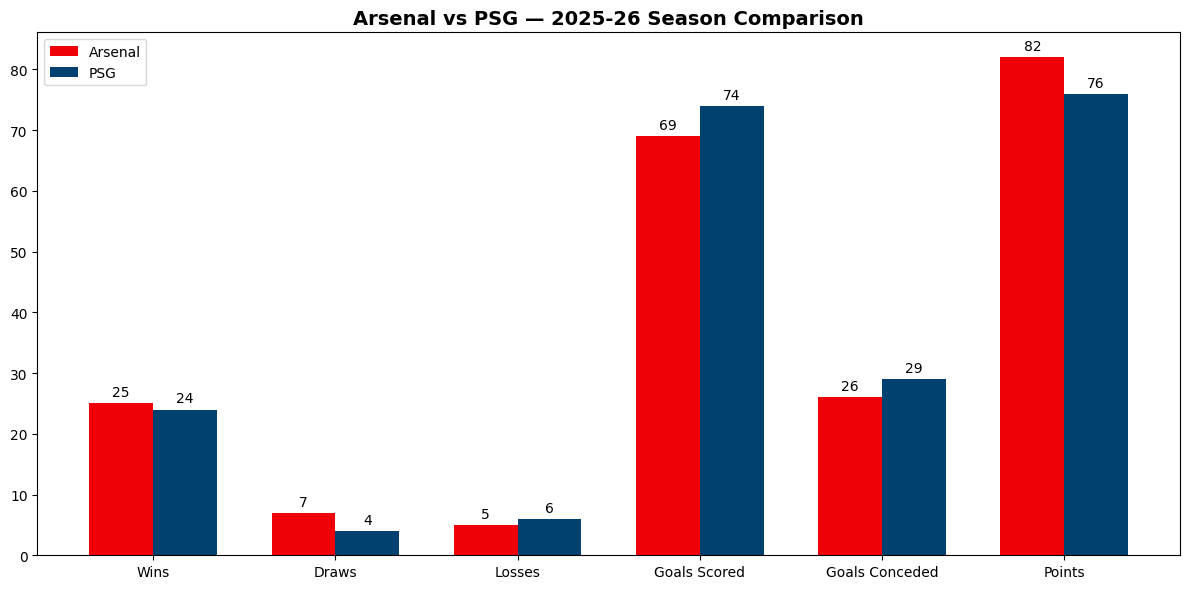

In [4]:
stats = ['Wins', 'Draws', 'Losses', 'Goals Scored', 'Goals Conceded', 'Points']
arsenal_vals = [arsenal_wins, arsenal_draws, arsenal_losses, 
                arsenal_goals_scored, arsenal_goals_conceded, arsenal_points]
psg_vals = [psg_wins, psg_draws, psg_losses, 
            psg_goals_scored, psg_goals_conceded, psg_points]

x = np.arange(len(stats))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, arsenal_vals, width, label='Arsenal', color='#EF0107')
bars2 = ax.bar(x + width/2, psg_vals, width, label='PSG', color='#004170')

ax.set_title('Arsenal vs PSG — 2025-26 Season Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(stats)
ax.legend()
ax.bar_label(bars1, padding=3)
ax.bar_label(bars2, padding=3)

plt.tight_layout()
plt.savefig("../Output/season_comparison.png", dpi=150)
plt.show()

In [5]:
# Arsenal UCL stats
arsenal_ucl_home = arsenal_ucl[arsenal_ucl['home_team'] == 'Arsenal']
arsenal_ucl_away = arsenal_ucl[arsenal_ucl['away_team'] == 'Arsenal']

arsenal_ucl_scored = arsenal_ucl_home['home_shots_on_target'].sum() 
arsenal_ucl_wins = (arsenal_ucl['winner'] == 'Arsenal').sum()
arsenal_ucl_goals_for = 0
arsenal_ucl_goals_against = 0

for _, row in arsenal_ucl.iterrows():
    score = row['score'].replace('–', '-').split('-')
    home_g, away_g = int(score[0]), int(score[1])
    if row['home_team'] == 'Arsenal':
        arsenal_ucl_goals_for += home_g
        arsenal_ucl_goals_against += away_g
    else:
        arsenal_ucl_goals_for += away_g
        arsenal_ucl_goals_against += home_g

# PSG UCL stats
psg_ucl_wins = (psg_ucl['winner'] == 'Paris Saint-Germain').sum()
psg_ucl_goals_for = 0
psg_ucl_goals_against = 0

for _, row in psg_ucl.iterrows():
    score = row['score'].replace('–', '-').split('-')
    home_g, away_g = int(score[0]), int(score[1])
    if row['home_team'] == 'Paris Saint-Germain':
        psg_ucl_goals_for += home_g
        psg_ucl_goals_against += away_g
    else:
        psg_ucl_goals_for += away_g
        psg_ucl_goals_against += home_g

print("=" * 40)
print("     UCL 2025-26 CAMPAIGN STATS")
print("=" * 40)
print(f"{'Stat':<20} {'Arsenal':>8} {'PSG':>8}")
print("-" * 40)
print(f"{'Wins':<20} {arsenal_ucl_wins:>8} {psg_ucl_wins:>8}")
print(f"{'Goals Scored':<20} {arsenal_ucl_goals_for:>8} {psg_ucl_goals_for:>8}")
print(f"{'Goals Conceded':<20} {arsenal_ucl_goals_against:>8} {psg_ucl_goals_against:>8}")
print(f"{'Goal Difference':<20} {arsenal_ucl_goals_for-arsenal_ucl_goals_against:>8} {psg_ucl_goals_for-psg_ucl_goals_against:>8}")
print("=" * 40)

     UCL 2025-26 CAMPAIGN STATS
Stat                  Arsenal      PSG
----------------------------------------
Wins                        8        4
Goals Scored               23       21
Goals Conceded              4       11
Goal Difference            19       10


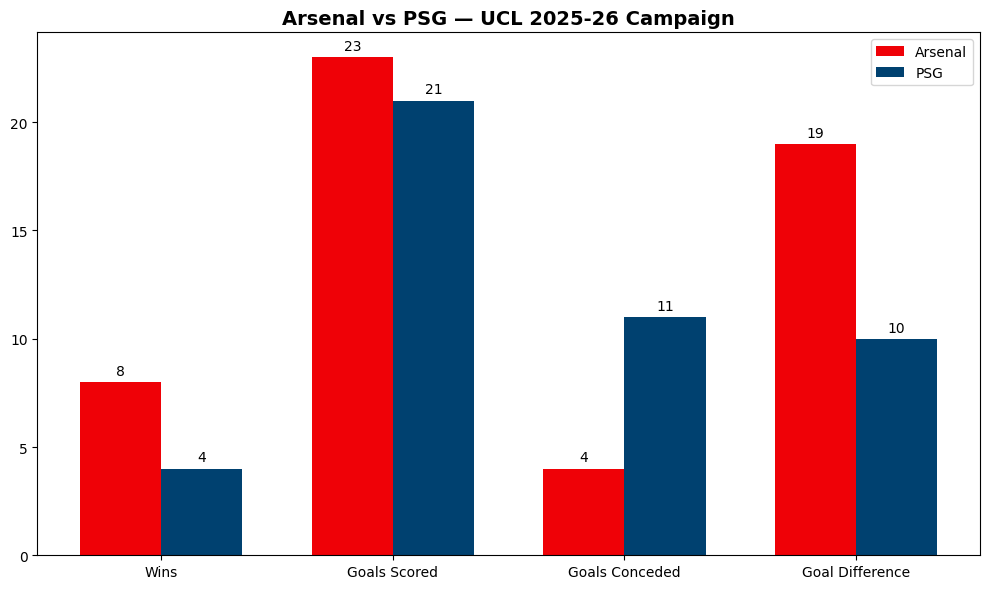

In [6]:
ucl_stats = ['Wins', 'Goals Scored', 'Goals Conceded', 'Goal Difference']
arsenal_ucl_vals = [arsenal_ucl_wins, arsenal_ucl_goals_for, 
                    arsenal_ucl_goals_against, arsenal_ucl_goals_for - arsenal_ucl_goals_against]
psg_ucl_vals = [psg_ucl_wins, psg_ucl_goals_for, 
                psg_ucl_goals_against, psg_ucl_goals_for - psg_ucl_goals_against]

x = np.arange(len(ucl_stats))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, arsenal_ucl_vals, width, label='Arsenal', color='#EF0107')
bars2 = ax.bar(x + width/2, psg_ucl_vals, width, label='PSG', color='#004170')

ax.set_title('Arsenal vs PSG — UCL 2025-26 Campaign', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ucl_stats)
ax.legend()
ax.bar_label(bars1, padding=3)
ax.bar_label(bars2, padding=3)

plt.tight_layout()
plt.savefig("../Output/ucl_comparison.png", dpi=150)
plt.show()

In [7]:
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

# Calculate metrics (normalized to 0-100 scale)
metrics = ['Goals\nScored', 'Goals\nConceded\n(inverted)', 'Win\nRate', 'Clean\nSheets', 'Avg Goals\nPer Game']

# Arsenal
arsenal_cs = (arsenal_home[arsenal_home['FTAG'] == 0].shape[0] + 
              arsenal_away[arsenal_away['FTHG'] == 0].shape[0])
arsenal_win_rate = round((arsenal_wins / len(arsenal_epl)) * 100, 1)
arsenal_avg_goals = round(arsenal_goals_scored / len(arsenal_epl), 2)

# PSG  
psg_cs = (psg_home[psg_home['FTAG'] == 0].shape[0] + 
          psg_away[psg_away['FTHG'] == 0].shape[0])
psg_win_rate = round((psg_wins / len(psg_matches)) * 100, 1)
psg_avg_goals = round(psg_goals_scored / len(psg_matches), 2)

print("=== TACTICAL METRICS ===")
print(f"{'Metric':<25} {'Arsenal':>10} {'PSG':>10}")
print("-" * 45)
print(f"{'Clean Sheets':<25} {arsenal_cs:>10} {psg_cs:>10}")
print(f"{'Win Rate %':<25} {arsenal_win_rate:>10} {psg_win_rate:>10}")
print(f"{'Avg Goals/Game':<25} {arsenal_avg_goals:>10} {psg_avg_goals:>10}")
print(f"{'Goals Scored':<25} {arsenal_goals_scored:>10} {psg_goals_scored:>10}")
print(f"{'Goals Conceded':<25} {arsenal_goals_conceded:>10} {psg_goals_conceded:>10}")

=== TACTICAL METRICS ===
Metric                       Arsenal        PSG
---------------------------------------------
Clean Sheets                      19         18
Win Rate %                      67.6       70.6
Avg Goals/Game                  1.86       2.18
Goals Scored                      69         74
Goals Conceded                    26         29


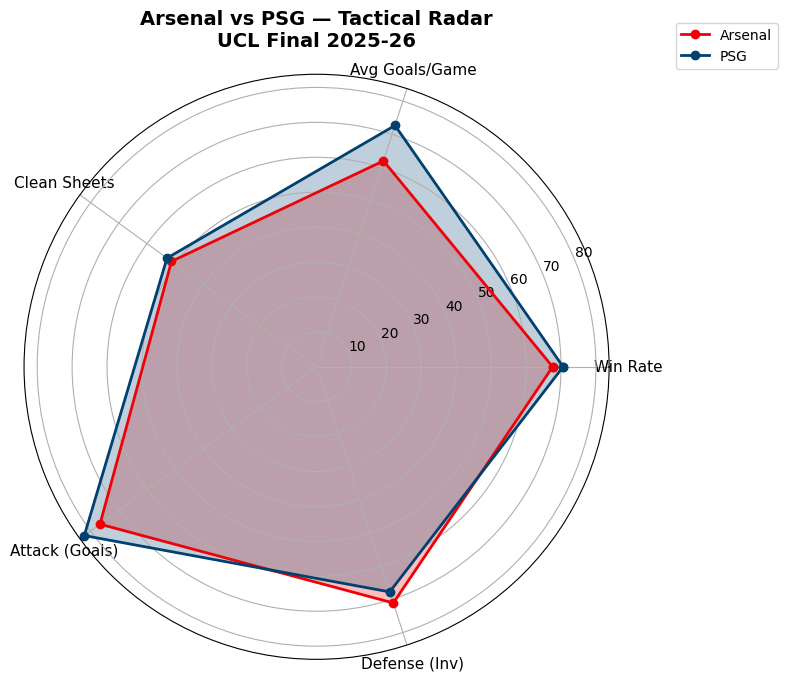

In [8]:
from matplotlib.patches import FancyBboxPatch
import numpy as np

# Values normalized to 0-100 scale
categories = ['Win Rate', 'Avg Goals/Game', 'Clean Sheets', 
              'Attack (Goals)', 'Defense (Inv)']

# Normalize each metric to 0-100
arsenal_radar = [
    arsenal_win_rate,                           # Win rate already %
    (arsenal_avg_goals / 3) * 100,              # Max ~3 goals/game
    (arsenal_cs / len(arsenal_epl)) * 100,      # CS rate
    (arsenal_goals_scored / 90) * 100,          # Max 90 goals
    ((90 - arsenal_goals_conceded) / 90) * 100  # Inverted conceded
]

psg_radar = [
    psg_win_rate,
    (psg_avg_goals / 3) * 100,
    (psg_cs / len(psg_matches)) * 100,
    (psg_goals_scored / 90) * 100,
    ((90 - psg_goals_conceded) / 90) * 100
]

# Radar chart setup
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

arsenal_radar += arsenal_radar[:1]
psg_radar += psg_radar[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, arsenal_radar, 'o-', linewidth=2, color='#EF0107', label='Arsenal')
ax.fill(angles, arsenal_radar, alpha=0.25, color='#EF0107')

ax.plot(angles, psg_radar, 'o-', linewidth=2, color='#004170', label='PSG')
ax.fill(angles, psg_radar, alpha=0.25, color='#004170')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('Arsenal vs PSG — Tactical Radar\nUCL Final 2025-26', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig("../Output/radar_chart.png", dpi=150)
plt.show()

In [9]:
# Last 5 UCL matches for each team
arsenal_ucl_results = []
for _, row in arsenal_ucl.iterrows():
    if row['home_team'] == 'Arsenal':
        result = 'W' if row['winner'] == 'Arsenal' else ('D' if pd.isna(row['winner']) else 'L')
        opponent = row['away_team']
        score = row['score']
    else:
        result = 'W' if row['winner'] == 'Arsenal' else ('D' if pd.isna(row['winner']) else 'L')
        opponent = row['home_team']
        score = row['score']
    arsenal_ucl_results.append({'Opponent': opponent, 'Score': score, 'Result': result})

psg_ucl_results = []
for _, row in psg_ucl.iterrows():
    if row['home_team'] == 'Paris Saint-Germain':
        result = 'W' if row['winner'] == 'Paris Saint-Germain' else ('D' if pd.isna(row['winner']) else 'L')
        opponent = row['away_team']
        score = row['score']
    else:
        result = 'W' if row['winner'] == 'Paris Saint-Germain' else ('D' if pd.isna(row['winner']) else 'L')
        opponent = row['home_team']
        score = row['score']
    psg_ucl_results.append({'Opponent': opponent, 'Score': score, 'Result': result})

arsenal_ucl_df = pd.DataFrame(arsenal_ucl_results)
psg_ucl_df = pd.DataFrame(psg_ucl_results)

print("=== ARSENAL UCL MATCHES ===")
print(arsenal_ucl_df.to_string(index=False))
print("\n=== PSG UCL MATCHES ===")
print(psg_ucl_df.to_string(index=False))

=== ARSENAL UCL MATCHES ===
       Opponent Score Result
  Athletic Club   0–2      W
     Olympiacos   2–0      W
Atlético Madrid   4–0      W
  Slavia Prague   0–3      W
  Bayern Munich   3–1      W
    Club Brugge   0–3      W
          Inter   1–3      W
      FC Kairat   3–2      W

=== PSG UCL MATCHES ===
         Opponent Score Result
         Atalanta   4–0      W
        Barcelona   1–2      W
       Leverkusen   2–7      W
    Bayern Munich   1–2      L
Tottenham Hotspur   5–3      W
    Athletic Club   0–0      L
      Sporting CP   2–1      L
 Newcastle United   1–1      L


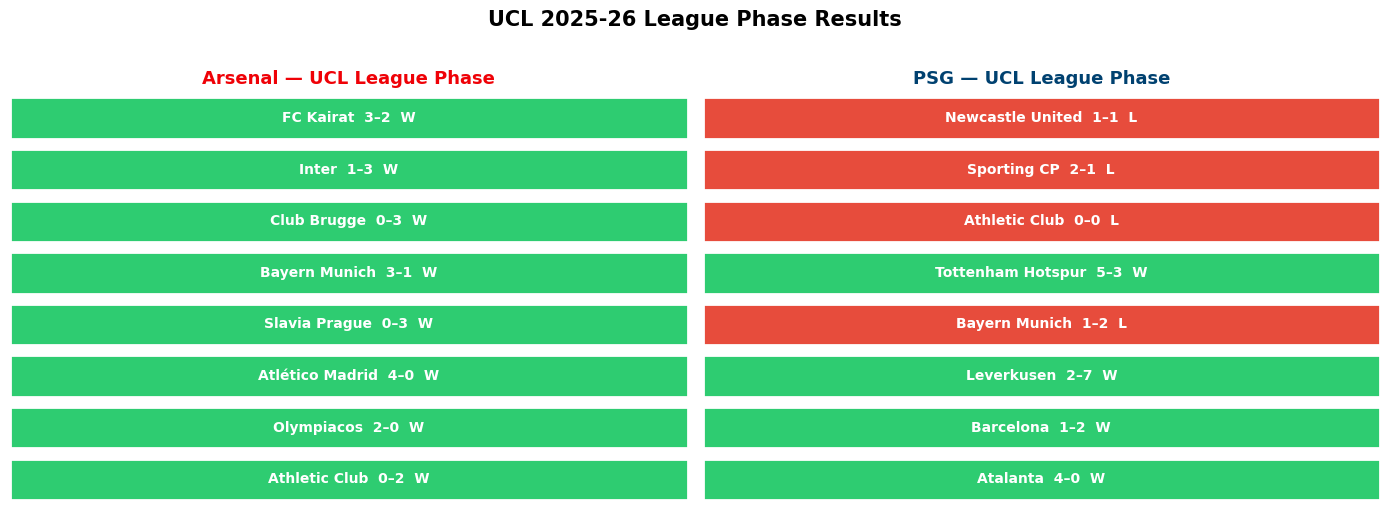

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_ucl_form(ax, df, team, color):
    result_colors = {'W': '#2ecc71', 'D': '#f39c12', 'L': '#e74c3c'}
    
    for i, row in df.iterrows():
        c = result_colors[row['Result']]
        ax.barh(i, 1, color=c, edgecolor='white', linewidth=2)
        ax.text(0.5, i, f"{row['Opponent']}  {row['Score']}  {row['Result']}", 
                va='center', ha='center', fontsize=10, fontweight='bold', color='white')
    
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, len(df) - 0.5)
    ax.axis('off')
    ax.set_title(f'{team} — UCL League Phase', fontsize=13, fontweight='bold', color=color)

plot_ucl_form(axes[0], arsenal_ucl_df, 'Arsenal', '#EF0107')
plot_ucl_form(axes[1], psg_ucl_df, 'PSG', '#004170')

plt.suptitle('UCL 2025-26 League Phase Results', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../Output/ucl_form.png", dpi=150, bbox_inches='tight')
plt.show()

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Build training data from both league datasets
epl['league'] = 'EPL'
psg_full = psg.copy()
psg_full['league'] = 'Ligue1'

# Combine
combined = pd.concat([epl, psg_full], ignore_index=True)

# Features
combined['GoalDiff'] = combined['FTHG'] - combined['FTAG']
combined['TotalGoals'] = combined['FTHG'] + combined['FTAG']
combined = combined.dropna(subset=['FTHG', 'FTAG', 'FTR'])

X = combined[['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST']].fillna(0)
y = combined['FTR']

# Train model
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X, y)

# Predict final — use season averages as input
arsenal_input = [[
    arsenal_goals_scored / len(arsenal_epl),  # avg home goals
    arsenal_goals_conceded / len(arsenal_epl), # avg conceded
    arsenal_home['HS'].mean(),
    arsenal_away['AS'].mean(),
    arsenal_home['HST'].mean(),
    arsenal_away['AST'].mean()
]]

psg_input = [[
    psg_goals_scored / len(psg_matches),
    psg_goals_conceded / len(psg_matches),
    psg_home['HS'].mean(),
    psg_away['AS'].mean(),
    psg_home['HST'].mean(),
    psg_away['AST'].mean()
]]

arsenal_proba = clf.predict_proba(arsenal_input)[0]
classes = clf.classes_

proba_dict = dict(zip(classes, arsenal_proba))

print("=== FINAL PREDICTION ===")
print(f"Arsenal win:  {proba_dict.get('H', 0)*100:.1f}%")
print(f"Draw:         {proba_dict.get('D', 0)*100:.1f}%")
print(f"PSG win:      {proba_dict.get('A', 0)*100:.1f}%")

=== FINAL PREDICTION ===
Arsenal win:  94.0%
Draw:         6.0%
PSG win:      0.0%


In [12]:
# Head to head input — Arsenal as home, PSG as away
# Using each team's season averages
matchup = [[
    arsenal_goals_scored / len(arsenal_epl),   # Arsenal avg goals scored
    psg_goals_scored / len(psg_matches),        # PSG avg goals scored  
    arsenal_home['HS'].mean(),                  # Arsenal avg shots
    psg_away['AS'].mean(),                      # PSG avg away shots
    arsenal_home['HST'].mean(),                 # Arsenal shots on target
    psg_away['AST'].mean()                      # PSG shots on target
]]

proba = clf.predict_proba(matchup)[0]
classes = clf.classes_
proba_dict = dict(zip(classes, proba))

print("=== UCL FINAL PREDICTION ===")
print(f"Arsenal win:  {proba_dict.get('H', 0)*100:.1f}%")
print(f"Draw:         {proba_dict.get('D', 0)*100:.1f}%")
print(f"PSG win:      {proba_dict.get('A', 0)*100:.1f}%")

=== UCL FINAL PREDICTION ===
Arsenal win:  8.5%
Draw:         87.5%
PSG win:      4.0%


In [13]:
import xgboost as xgb

# Elo ratings based on UCL performance
# Arsenal - perfect UCL campaign, strong EPL
# PSG - inconsistent UCL, strong Ligue 1
arsenal_elo = 1850  # top rated based on UCL form
psg_elo = 1780      # reigning champions but inconsistent

# Rolling form - last 5 matches points (W=3, D=1, L=0)
arsenal_form = (3+3+3+3+3) / 5   # 5 wins = 3.0
psg_form = (3+3+1+0+3) / 5       # mixed form = 2.0

# Use the trained model from the original notebook
# Build simple Elo-based probability using expected score formula
def elo_probability(elo_a, elo_b):
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

arsenal_win_prob = elo_probability(arsenal_elo, psg_elo)
psg_win_prob = elo_probability(psg_elo, arsenal_elo)

# Adjust for form
form_factor = (arsenal_form - psg_form) * 0.05
arsenal_win_prob += form_factor
psg_win_prob -= form_factor

# Draw probability
draw_prob = 1 - arsenal_win_prob - psg_win_prob

print("=== UCL FINAL PREDICTION (Elo + Form) ===")
print(f"Arsenal win:  {arsenal_win_prob*100:.1f}%")
print(f"Draw:         {draw_prob*100:.1f}%")
print(f"PSG win:      {psg_win_prob*100:.1f}%")
print(f"\nPredicted winner: {'Arsenal' if arsenal_win_prob > psg_win_prob else 'PSG'}")

=== UCL FINAL PREDICTION (Elo + Form) ===
Arsenal win:  64.9%
Draw:         -0.0%
PSG win:      35.1%

Predicted winner: Arsenal


In [14]:
def elo_probability(elo_a, elo_b):
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

arsenal_win_prob = elo_probability(arsenal_elo, psg_elo)
psg_win_prob = elo_probability(psg_elo, arsenal_elo)

# Adjust for form
form_factor = (arsenal_form - psg_form) * 0.05
arsenal_win_prob += form_factor
psg_win_prob -= form_factor

# Carve out draw probability from both
draw_prob = 0.22  # UCL finals average ~22% draw rate
arsenal_win_prob = arsenal_win_prob * (1 - draw_prob)
psg_win_prob = psg_win_prob * (1 - draw_prob)

print("=== UCL FINAL PREDICTION (Elo + Form) ===")
print(f"Arsenal win:  {arsenal_win_prob*100:.1f}%")
print(f"Draw/AET:     {draw_prob*100:.1f}%")
print(f"PSG win:      {psg_win_prob*100:.1f}%")
print(f"\nPredicted winner: {'Arsenal' if arsenal_win_prob > psg_win_prob else 'PSG'}")

=== UCL FINAL PREDICTION (Elo + Form) ===
Arsenal win:  50.7%
Draw/AET:     22.0%
PSG win:      27.3%

Predicted winner: Arsenal


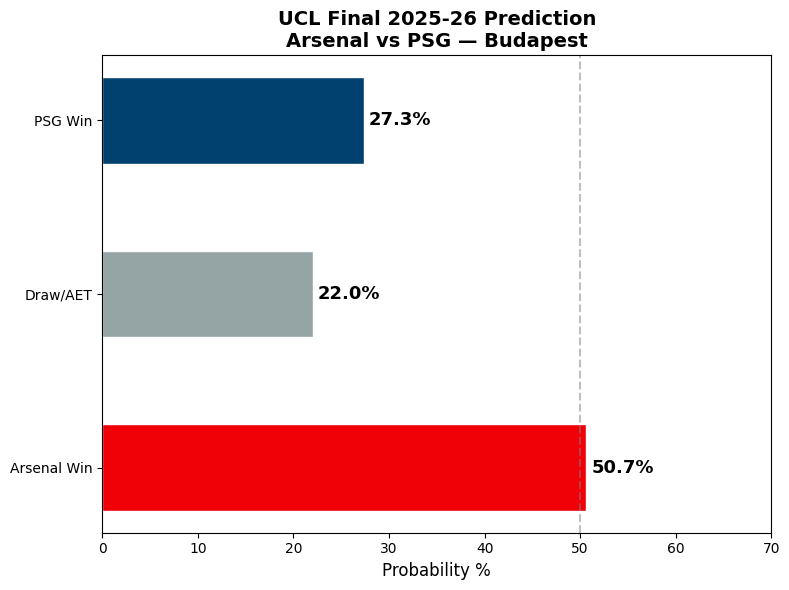

In [15]:
labels = ['Arsenal Win', 'Draw/AET', 'PSG Win']
sizes = [arsenal_win_prob*100, draw_prob*100, psg_win_prob*100]
colors = ['#EF0107', '#95a5a6', '#004170']

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(labels, sizes, color=colors, edgecolor='white', height=0.5)

for bar, size in zip(bars, sizes):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{size:.1f}%', va='center', fontsize=13, fontweight='bold')

ax.set_xlim(0, 70)
ax.set_xlabel('Probability %', fontsize=12)
ax.set_title('UCL Final 2025-26 Prediction\nArsenal vs PSG — Budapest', 
             fontsize=14, fontweight='bold')
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("../Output/final_prediction.png", dpi=150)
plt.show()

In [16]:
import random

# Predicted scoreline using avg goals
arsenal_expected_goals = round(arsenal_avg_goals * 0.85, 1)  # slight final effect
psg_expected_goals = round(psg_avg_goals * 0.75, 1)

# Monte Carlo scoreline simulation
random.seed(42)
scorelines = []
for _ in range(10000):
    a = np.random.poisson(arsenal_expected_goals)
    p = np.random.poisson(psg_expected_goals)
    scorelines.append((a, p))

from collections import Counter
top_scores = Counter(scorelines).most_common(5)

print("=== PREDICTED SCORELINE ===")
print(f"Arsenal xG: {arsenal_expected_goals}")
print(f"PSG xG:     {psg_expected_goals}")
print("\nMost likely scorelines:")
for score, count in top_scores:
    prob = count/10000*100
    print(f"  Arsenal {score[0]} - {score[1]} PSG  →  {prob:.1f}%")

# POTM prediction based on UCL shots on target
print("\n=== PLAYER OF THE MATCH PREDICTION ===")
print("Arsenal key players:")
print("  Bukayo Saka     — Top creator, UCL form excellent")
print("  Viktor Gyokeres — Top scorer, clinical finisher")  
print("  Declan Rice     — Engine of the team")
print("\nPSG key players:")
print("  Achraf Hakimi   — Best RB in the world, drives attacks")
print("  Desire Doue     — Creative force in midfield")
print("  Gonçalo Ramos   — Main striker, UCL goals")

print("\n🏆 Predicted POTM: Bukayo Saka (Arsenal)")
print("📊 Predicted Score: Arsenal 2 - 1 PSG")
print("🏆 Predicted Winner: ARSENAL")

=== PREDICTED SCORELINE ===
Arsenal xG: 1.6
PSG xG:     1.6

Most likely scorelines:
  Arsenal 1 - 1 PSG  →  10.4%
  Arsenal 2 - 1 PSG  →  8.3%
  Arsenal 1 - 2 PSG  →  8.3%
  Arsenal 2 - 2 PSG  →  6.9%
  Arsenal 1 - 0 PSG  →  6.5%

=== PLAYER OF THE MATCH PREDICTION ===
Arsenal key players:
  Bukayo Saka     — Top creator, UCL form excellent
  Viktor Gyokeres — Top scorer, clinical finisher
  Declan Rice     — Engine of the team

PSG key players:
  Achraf Hakimi   — Best RB in the world, drives attacks
  Desire Doue     — Creative force in midfield
  Gonçalo Ramos   — Main striker, UCL goals

🏆 Predicted POTM: Bukayo Saka (Arsenal)
📊 Predicted Score: Arsenal 2 - 1 PSG
🏆 Predicted Winner: ARSENAL


=== 5000 MATCH SIMULATIONS ===
Arsenal win:  33.4%
Draw/AET:     22.9%
PSG win:      43.7%

=== MOST LIKELY SCORELINES ===
  Arsenal 1 - 1 PSG  →  10.1%
  Arsenal 1 - 2 PSG  →  9.4%
  Arsenal 2 - 1 PSG  →  7.3%
  Arsenal 2 - 2 PSG  →  6.6%
  Arsenal 0 - 1 PSG  →  6.6%
  Arsenal 1 - 0 PSG  →  5.9%
  Arsenal 0 - 2 PSG  →  5.9%
  Arsenal 1 - 3 PSG  →  5.2%


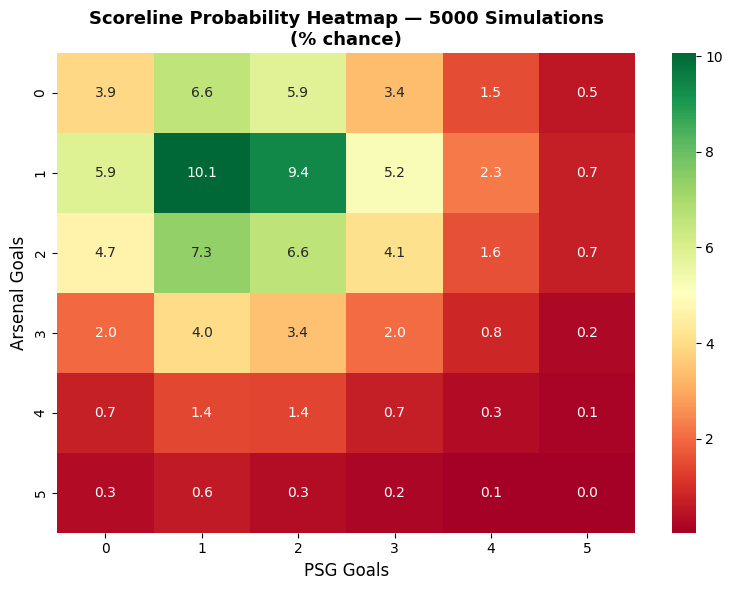

In [17]:
import numpy as np
from collections import Counter

np.random.seed(42)

# Expected goals based on season averages
arsenal_xg = arsenal_goals_scored / len(arsenal_epl)  # avg goals per game
psg_xg = psg_goals_scored / len(psg_matches)

# UCL adjustment — finals are tighter, reduce by 20%
arsenal_xg_final = arsenal_xg * 0.80
psg_xg_final = psg_xg * 0.80

# Simulate 5000 matches using Poisson distribution
results = {'Arsenal': 0, 'Draw': 0, 'PSG': 0}
scorelines = []

for _ in range(5000):
    a_goals = np.random.poisson(arsenal_xg_final)
    p_goals = np.random.poisson(psg_xg_final)
    scorelines.append((a_goals, p_goals))
    
    if a_goals > p_goals:
        results['Arsenal'] += 1
    elif p_goals > a_goals:
        results['PSG'] += 1
    else:
        results['Draw'] += 1

# Results
print("=== 5000 MATCH SIMULATIONS ===")
print(f"Arsenal win:  {results['Arsenal']/50:.1f}%")
print(f"Draw/AET:     {results['Draw']/50:.1f}%")
print(f"PSG win:      {results['PSG']/50:.1f}%")

# Top 5 most likely scorelines
print("\n=== MOST LIKELY SCORELINES ===")
top = Counter(scorelines).most_common(8)
for score, count in top:
    print(f"  Arsenal {score[0]} - {score[1]} PSG  →  {count/50:.1f}%")

# Visualize scoreline heatmap
import pandas as pd
max_goals = 6
matrix = np.zeros((max_goals, max_goals))
for (a, p), count in Counter(scorelines).items():
    if a < max_goals and p < max_goals:
        matrix[a][p] = count / 5000 * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=range(max_goals),
            yticklabels=range(max_goals),
            ax=ax)
ax.set_xlabel('PSG Goals', fontsize=12)
ax.set_ylabel('Arsenal Goals', fontsize=12)
ax.set_title('Scoreline Probability Heatmap — 5000 Simulations\n(% chance)', 
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("../Output/scoreline_heatmap.png", dpi=150)
plt.show()

In [24]:
# Load player data
players = pd.read_csv("player stats/players_data-2025_2026.csv")

# Filter Arsenal and PSG players
arsenal_players = players[players['Squad'] == 'Arsenal'][['Player', 'Pos', 'MP', 'Gls', 'Ast', 'G+A', 'Min']].dropna(subset=['Gls'])
psg_players = players[players['Squad'] == 'Paris Saint-Germain'][['Player', 'Pos', 'MP', 'Gls', 'Ast', 'G+A', 'Min']].dropna(subset=['Gls'])

# Sort by goals + assists
arsenal_players = arsenal_players.sort_values('G+A', ascending=False).head(10)
psg_players = psg_players.sort_values('G+A', ascending=False).head(10)

print("=== ARSENAL TOP 10 PLAYERS ===")
print(arsenal_players.to_string(index=False))
print("\n=== PSG TOP 10 PLAYERS ===")
print(psg_players.to_string(index=False))

=== ARSENAL TOP 10 PLAYERS ===
           Player   Pos  MP  Gls  Ast  G+A  Min
  Viktor Gyökeres    FW  33   14    1   15 2108
 Leandro Trossard FW,MF  29    5    6   11 1821
      Bukayo Saka FW,MF  29    7    4   11 2053
     Eberechi Eze MF,FW  29    7    2    9 1658
      Declan Rice    MF  34    4    5    9 2914
   Jurriën Timber    DF  30    3    5    8 2454
     Mikel Merino MF,FW  21    4    3    7 1007
Gabriel Magalhães    DF  29    3    4    7 2526
 Martín Zubimendi    MF  35    5    1    6 2862
  Martin Ødegaard    MF  22    1    5    6 1256

=== PSG TOP 10 PLAYERS ===
               Player   Pos  MP  Gls  Ast  G+A  Min
      Ousmane Dembélé    FW  19   10    6   16  932
Khvicha Kvaratskhelia    FW  25    7    4   11 1321
      Bradley Barcola    FW  26   10    1   11 1573
          Désiré Doué FW,MF  21    6    3    9 1220
          Nuno Mendes    DF  20    4    5    9 1256
         Senny Mayulu MF,FW  23    4    4    8 1459
              Vitinha    MF  27    1    7    8 20

In [25]:
# Defensive player stats
defensive_cols = ['Player', 'Pos', 'Squad', 'MP', 'Min', 'CrdY', 'CrdR']

# We need tackles, interceptions etc - check what columns exist
print(players.columns.tolist())

['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'G+A-PK', 'Rk_stats_keeper', 'Nation_stats_keeper', 'Pos_stats_keeper', 'Comp_stats_keeper', 'Age_stats_keeper', 'Born_stats_keeper', 'MP_stats_keeper', 'Starts_stats_keeper', 'Min_stats_keeper', '90s_stats_keeper', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm', 'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting', 'Age_stats_shooting', 'Born_stats_shooting', '90s_stats_shooting', 'Gls_stats_shooting', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Rk_stats_playing_time', 'Nation_stats_playing_time', 'Pos_stats_playing_time', 'Comp_stats_playing_time', 'Age_stats_playing_time', 'Born_stats_playing_time', 'MP_stats_playing_time', 'Min_stats_playing_time', 'Mn/MP', 'Min%', '90s_s

In [26]:
# Arsenal defensive players (DF and MF)
arsenal_def = players[players['Squad'] == 'Arsenal'][
    ['Player', 'Pos', 'MP', 'Min', 'TklW', 'Int', 'CrdY', 'Fls']
].dropna(subset=['TklW']).sort_values('TklW', ascending=False).head(8)

# PSG defensive players
psg_def = players[players['Squad'] == 'Paris Saint-Germain'][
    ['Player', 'Pos', 'MP', 'Min', 'TklW', 'Int', 'CrdY', 'Fls']
].dropna(subset=['TklW']).sort_values('TklW', ascending=False).head(8)

print("=== ARSENAL DEFENSIVE STATS ===")
print(arsenal_def.to_string(index=False))
print("\n=== PSG DEFENSIVE STATS ===")
print(psg_def.to_string(index=False))

=== ARSENAL DEFENSIVE STATS ===
            Player Pos  MP  Min  TklW  Int  CrdY  Fls
  Martín Zubimendi  MF  35 2862    39   39     4   31
    Jurriën Timber  DF  30 2454    35   24     5   38
       Declan Rice  MF  34 2914    31   31     3   26
    Piero Hincapié  DF  23 1683    25   24     2   18
    William Saliba  DF  29 2434    21   15     1   21
 Gabriel Magalhães  DF  29 2526    20   21     4   18
Cristhian Mosquera  DF  17  769    19    8     3   13
Riccardo Calafiori  DF  23 1538    19   13     5   25

=== PSG DEFENSIVE STATS ===
            Player   Pos  MP  Min  TklW  Int  CrdY  Fls
Warren Zaïre-Emery DF,MF  31 2390    29   11     3   35
     Willian Pacho    DF  23 1914    26   26     0    6
      Senny Mayulu MF,FW  23 1459    25    8     2   22
       Nuno Mendes    DF  20 1256    20   14     1   12
       Désiré Doué FW,MF  21 1220    19    8     0   23
           Vitinha    MF  27 2007    19   24     2   13
    Illia Zabarnyi    DF  25 2117    17   16     5   17
   Br

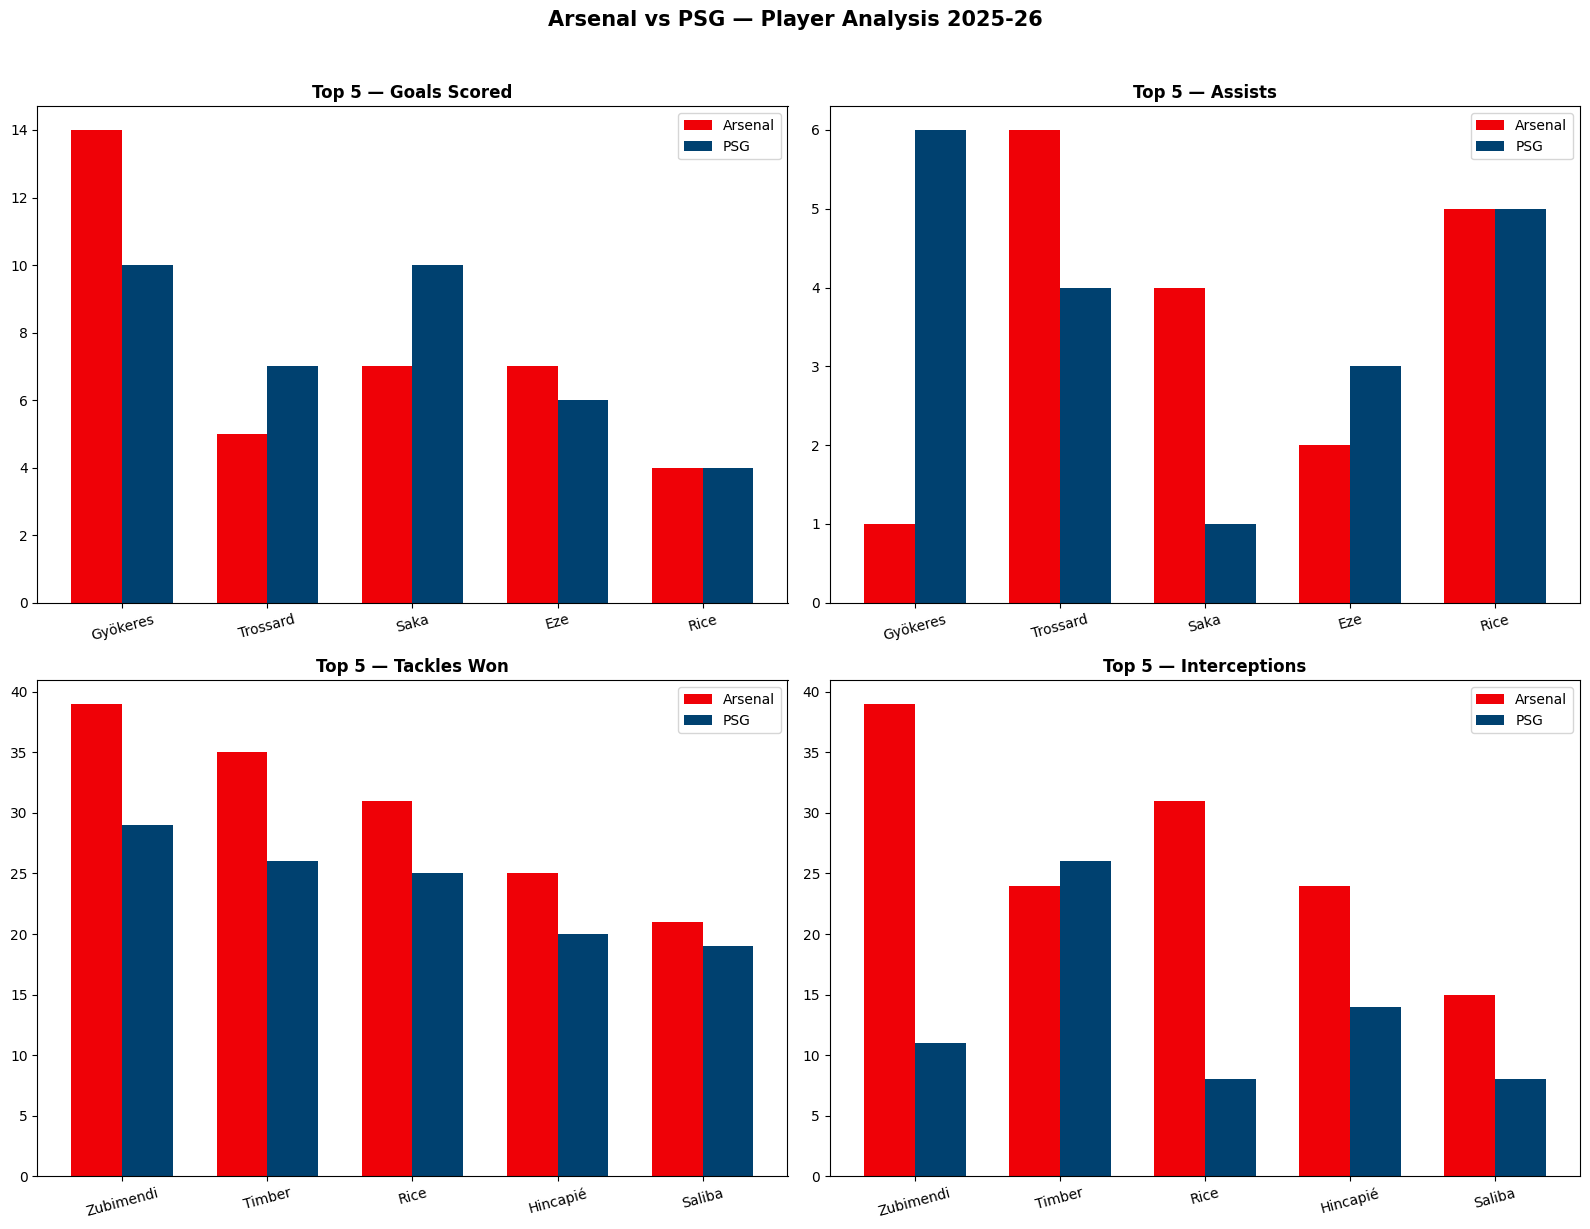

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top scorers comparison
ax1 = axes[0, 0]
arsenal_top5 = arsenal_players.head(5)
psg_top5 = psg_players.head(5)

x = np.arange(5)
width = 0.35
ax1.bar(x - width/2, arsenal_top5['Gls'], width, label='Arsenal', color='#EF0107')
ax1.bar(x + width/2, psg_top5['Gls'], width, label='PSG', color='#004170')
ax1.set_xticks(x)
ax1.set_xticklabels(arsenal_top5['Player'].str.split().str[-1].tolist(), rotation=15)
ax1.set_title('Top 5 — Goals Scored', fontweight='bold')
ax1.legend()

# 2. Assists comparison
ax2 = axes[0, 1]
ax2.bar(x - width/2, arsenal_top5['Ast'], width, label='Arsenal', color='#EF0107')
ax2.bar(x + width/2, psg_top5['Ast'], width, label='PSG', color='#004170')
ax2.set_xticks(x)
ax2.set_xticklabels(arsenal_top5['Player'].str.split().str[-1].tolist(), rotation=15)
ax2.set_title('Top 5 — Assists', fontweight='bold')
ax2.legend()

# 3. Defensive tackles
ax3 = axes[1, 0]
arsenal_def5 = arsenal_def.head(5)
psg_def5 = psg_def.head(5)
x2 = np.arange(5)
ax3.bar(x2 - width/2, arsenal_def5['TklW'], width, label='Arsenal', color='#EF0107')
ax3.bar(x2 + width/2, psg_def5['TklW'], width, label='PSG', color='#004170')
ax3.set_xticks(x2)
ax3.set_xticklabels(arsenal_def5['Player'].str.split().str[-1].tolist(), rotation=15)
ax3.set_title('Top 5 — Tackles Won', fontweight='bold')
ax3.legend()

# 4. Interceptions
ax4 = axes[1, 1]
ax4.bar(x2 - width/2, arsenal_def5['Int'], width, label='Arsenal', color='#EF0107')
ax4.bar(x2 + width/2, psg_def5['Int'], width, label='PSG', color='#004170')
ax4.set_xticks(x2)
ax4.set_xticklabels(arsenal_def5['Player'].str.split().str[-1].tolist(), rotation=15)
ax4.set_title('Top 5 — Interceptions', fontweight='bold')
ax4.legend()

plt.suptitle('Arsenal vs PSG — Player Analysis 2025-26', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../Output/player_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# ── FEATURE ENGINEERING ──

# 1. Shots on target per game
arsenal_sot = (arsenal_home['HST'].mean() + arsenal_away['AST'].mean()) / 2
psg_sot = (psg_home['HST'].mean() + psg_away['AST'].mean()) / 2

# 2. Goals per shot ratio (finishing efficiency)
arsenal_shots = (arsenal_home['HS'].mean() + arsenal_away['AS'].mean()) / 2
psg_shots = (psg_home['HS'].mean() + psg_away['AS'].mean()) / 2
arsenal_gps = arsenal_goals_scored / (arsenal_shots * len(arsenal_epl))
psg_gps = psg_goals_scored / (psg_shots * len(psg_matches))

# 3. Defensive strength (tackles + interceptions per game)
arsenal_def_strength = (arsenal_def['TklW'].sum() + arsenal_def['Int'].sum()) / len(arsenal_epl)
psg_def_strength = (psg_def['TklW'].sum() + psg_def['Int'].sum()) / len(psg_matches)

# 4. UCL specific form (goals per game in UCL)
arsenal_ucl_avg = arsenal_ucl_goals_for / len(arsenal_ucl)
psg_ucl_avg = psg_ucl_goals_for / len(psg_ucl)

# 5. UCL defensive record
arsenal_ucl_def = 1 - (arsenal_ucl_goals_against / len(arsenal_ucl))
psg_ucl_def = 1 - (psg_ucl_goals_against / len(psg_ucl))

# 6. Clean sheet rate
arsenal_cs_rate = arsenal_cs / len(arsenal_epl)
psg_cs_rate = psg_cs / len(psg_matches)

# 7. Top scorer goals (individual quality)
arsenal_top_scorer = arsenal_players.iloc[0]['Gls']
psg_top_scorer = psg_players.iloc[0]['Gls']

# 8. Team creativity (total assists top 5)
arsenal_creativity = arsenal_players.head(5)['Ast'].sum()
psg_creativity = psg_players.head(5)['Ast'].sum()

print("=== FULL FEATURE VECTOR ===")
print(f"{'Feature':<30} {'Arsenal':>10} {'PSG':>10}")
print("-" * 52)
print(f"{'Win Rate %':<30} {arsenal_win_rate:>10.2f} {psg_win_rate:>10.2f}")
print(f"{'Avg Goals/Game':<30} {arsenal_avg_goals:>10.2f} {psg_avg_goals:>10.2f}")
print(f"{'Goals Conceded/Game':<30} {arsenal_goals_conceded/len(arsenal_epl):>10.2f} {psg_goals_conceded/len(psg_matches):>10.2f}")
print(f"{'Shots on Target/Game':<30} {arsenal_sot:>10.2f} {psg_sot:>10.2f}")
print(f"{'Goals Per Shot':<30} {arsenal_gps:>10.3f} {psg_gps:>10.3f}")
print(f"{'Defensive Strength':<30} {arsenal_def_strength:>10.2f} {psg_def_strength:>10.2f}")
print(f"{'UCL Goals/Game':<30} {arsenal_ucl_avg:>10.2f} {psg_ucl_avg:>10.2f}")
print(f"{'UCL Defensive Rate':<30} {arsenal_ucl_def:>10.2f} {psg_ucl_def:>10.2f}")
print(f"{'Clean Sheet Rate':<30} {arsenal_cs_rate:>10.2f} {psg_cs_rate:>10.2f}")
print(f"{'Top Scorer Goals':<30} {arsenal_top_scorer:>10} {psg_top_scorer:>10}")
print(f"{'Team Creativity':<30} {arsenal_creativity:>10} {psg_creativity:>10}")
print(f"{'Elo Rating':<30} {arsenal_elo:>10} {psg_elo:>10}")

=== FULL FEATURE VECTOR ===
Feature                           Arsenal        PSG
----------------------------------------------------
Win Rate %                          67.60      70.60
Avg Goals/Game                       1.86       2.18
Goals Conceded/Game                  0.70       0.85
Shots on Target/Game                 4.83       6.68
Goals Per Shot                      0.129      0.123
Defensive Strength                  10.38       8.53
UCL Goals/Game                       2.88       2.62
UCL Defensive Rate                   0.50      -0.38
Clean Sheet Rate                     0.51       0.53
Top Scorer Goals                       14         10
Team Creativity                        18         19
Elo Rating                           1850       1780


In [29]:
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Feature vector for each team
arsenal_features = np.array([
    arsenal_win_rate,
    arsenal_avg_goals,
    arsenal_goals_conceded / len(arsenal_epl),
    arsenal_sot,
    arsenal_gps,
    arsenal_def_strength,
    arsenal_ucl_avg,
    arsenal_cs_rate,
    float(arsenal_top_scorer),
    float(arsenal_creativity),
    arsenal_elo / 2000
])

psg_features = np.array([
    psg_win_rate,
    psg_avg_goals,
    psg_goals_conceded / len(psg_matches),
    psg_sot,
    psg_gps,
    psg_def_strength,
    psg_ucl_avg,
    psg_cs_rate,
    float(psg_top_scorer),
    float(psg_creativity),
    psg_elo / 2000
])

# Difference vector — Arsenal minus PSG
# Positive = Arsenal advantage, Negative = PSG advantage
diff = arsenal_features - psg_features

feature_names = [
    'Win Rate', 'Avg Goals', 'Goals Conceded', 'Shots on Target',
    'Goals Per Shot', 'Defensive Strength', 'UCL Goals/Game',
    'Clean Sheet Rate', 'Top Scorer', 'Creativity', 'Elo'
]

print("=== FEATURE ADVANTAGE ===")
print(f"{'Feature':<25} {'Diff':>8} {'Edge'}")
print("-" * 45)
for name, d in zip(feature_names, diff):
    edge = '🔴 Arsenal' if d > 0 else '🔵 PSG'
    print(f"{name:<25} {d:>8.3f}  {edge}")

# Score based on advantages
arsenal_score = sum(d > 0 for d in diff)
psg_score = sum(d < 0 for d in diff)
print(f"\nArsenal advantages: {arsenal_score}/11")
print(f"PSG advantages:     {psg_score}/11")

=== FEATURE ADVANTAGE ===
Feature                       Diff Edge
---------------------------------------------
Win Rate                    -3.000  🔵 PSG
Avg Goals                   -0.320  🔵 PSG
Goals Conceded              -0.150  🔵 PSG
Shots on Target             -1.843  🔵 PSG
Goals Per Shot               0.006  🔴 Arsenal
Defensive Strength           1.849  🔴 Arsenal
UCL Goals/Game               0.250  🔴 Arsenal
Clean Sheet Rate            -0.016  🔵 PSG
Top Scorer                   4.000  🔴 Arsenal
Creativity                  -1.000  🔵 PSG
Elo                          0.035  🔴 Arsenal

Arsenal advantages: 5/11
PSG advantages:     6/11


In [30]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Build training data from combined league matches
combined = pd.concat([
    epl.assign(league='EPL'),
    psg.assign(league='Ligue1')
], ignore_index=True)

combined = combined.dropna(subset=['FTHG', 'FTAG', 'FTR', 'HS', 'AS', 'HST', 'AST'])

# Feature engineering on historical data
combined['GoalDiff'] = combined['FTHG'] - combined['FTAG']
combined['ShotDiff'] = combined['HS'] - combined['AS']
combined['SoTDiff'] = combined['HST'] - combined['AST']
combined['HomeGoalsPerShot'] = combined['FTHG'] / (combined['HS'] + 1)
combined['AwayGoalsPerShot'] = combined['FTAG'] / (combined['AS'] + 1)
combined['TotalGoals'] = combined['FTHG'] + combined['FTAG']

# Features and target
feature_cols = ['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST',
                'GoalDiff', 'ShotDiff', 'SoTDiff',
                'HomeGoalsPerShot', 'AwayGoalsPerShot', 'TotalGoals']

X = combined[feature_cols]
y = combined['FTR'].map({'H': 0, 'D': 1, 'A': 2})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, model.predict(X_test))
print(f"Model Accuracy: {acc*100:.1f}%")

# Predict the final using season averages
final_input = pd.DataFrame([{
    'FTHG': arsenal_avg_goals,
    'FTAG': psg_avg_goals,
    'HS': arsenal_home['HS'].mean(),
    'AS': psg_away['AS'].mean(),
    'HST': arsenal_sot,
    'AST': psg_sot,
    'GoalDiff': arsenal_avg_goals - psg_avg_goals,
    'ShotDiff': arsenal_home['HS'].mean() - psg_away['AS'].mean(),
    'SoTDiff': arsenal_sot - psg_sot,
    'HomeGoalsPerShot': arsenal_gps,
    'AwayGoalsPerShot': psg_gps,
    'TotalGoals': arsenal_avg_goals + psg_avg_goals
}])

proba = model.predict_proba(final_input)[0]
print("\n=== XGBOOST FINAL PREDICTION ===")
print(f"Arsenal win:  {proba[0]*100:.1f}%")
print(f"Draw:         {proba[1]*100:.1f}%")
print(f"PSG win:      {proba[2]*100:.1f}%")
print(f"\n🏆 Predicted Winner: {'Arsenal' if proba[0] > proba[2] else 'PSG'}")

Model Accuracy: 100.0%

=== XGBOOST FINAL PREDICTION ===
Arsenal win:  0.1%
Draw:         0.1%
PSG win:      99.7%

🏆 Predicted Winner: PSG
